# 06 - Prompt Experiment Analysis

Load every `*_phase2.json` produced by notebooks 01-05 and produce a comparison table + simple visualisations across `prompt x method`.

**Run notebooks 01-05 first**, in pilot or full mode.


In [2]:
import json
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path('../../results/prompt_experiment')
files = sorted(RESULTS_DIR.glob('*_phase2.json'))
print(f'Found {len(files)} phase2 files')
for f in files: print('  ', f.name)


Found 5 phase2 files
   P0_baseline__baseline_openai_phase2.json
   P1_strict_grounding__baseline_openai_phase2.json
   P2_zeroshot_cot__baseline_openai_phase2.json
   P3_fewshot_cot__baseline_openai_phase2.json
   P4_clinical_persona_cot__baseline_openai_phase2.json


In [3]:
def load_one(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    r = data['results']
    if not r: return None
    n = len(r)
    return {
        'file'             : path.stem,
        'prompt_id'        : data.get('prompt_id'),
        'method'           : data.get('method'),
        'n'                : n,
        'accuracy'         : sum(x['is_correct']        for x in r) / n,
        'faithfulness'     : sum(x['faithfulness']      for x in r) / n,
        'context_recall'   : sum(x['context_recall']    for x in r) / n,
        'answer_relevancy' : sum(x['answer_relevancy']  for x in r) / n,
        'context_precision': sum(x['context_precision'] for x in r) / n,
    }

rows = [load_one(p) for p in files]
rows = [r for r in rows if r]
df = pd.DataFrame(rows)
df = df.sort_values(['prompt_id', 'method']).reset_index(drop=True)
df


,file,prompt_id,method,n,accuracy,faithfulness,context_recall,answer_relevancy,context_precision
0,P0_baseline__baseline_openai_phase2,P0_baseline,baseline,100,0.68,0.899667,0.794214,0.980000,0.717611
1,P1_strict_grounding__baseline_openai_phase2,P1_strict_grounding,baseline,100,0.58,0.881333,0.797786,0.965167,0.722611
2,P2_zeroshot_cot__baseline_openai_phase2,P2_zeroshot_cot,baseline,100,0.58,0.792128,0.789214,0.907025,0.725944
3,P3_fewshot_cot__baseline_openai_phase2,P3_fewshot_cot,baseline,100,0.65,0.712679,0.802881,0.924262,0.730111
4,P4_clinical_persona_cot__baseline_openai_phase2,P4_clinical_persona_cot,baseline,100,0.45,0.815170,0.799214,0.798197,0.725111


## Pivot - prompt vs method, per metric


In [4]:
for metric in ['accuracy', 'faithfulness', 'context_recall',
               'answer_relevancy', 'context_precision']:
    print(f'\n=== {metric} ===')
    pivot = df.pivot(index='prompt_id', columns='method', values=metric)
    print(pivot.to_string(float_format=lambda x: f'{x:.3f}'))



=== accuracy ===
method                   baseline
prompt_id                        
P0_baseline                 0.680
P1_strict_grounding         0.580
P2_zeroshot_cot             0.580
P3_fewshot_cot              0.650
P4_clinical_persona_cot     0.450

=== faithfulness ===
method                   baseline
prompt_id                        
P0_baseline                 0.900
P1_strict_grounding         0.881
P2_zeroshot_cot             0.792
P3_fewshot_cot              0.713
P4_clinical_persona_cot     0.815

=== context_recall ===
method                   baseline
prompt_id                        
P0_baseline                 0.794
P1_strict_grounding         0.798
P2_zeroshot_cot             0.789
P3_fewshot_cot              0.803
P4_clinical_persona_cot     0.799

=== answer_relevancy ===
method                   baseline
prompt_id                        
P0_baseline                 0.980
P1_strict_grounding         0.965
P2_zeroshot_cot             0.907
P3_fewshot_cot            

## Per-label accuracy (yes / no / maybe)

Per-label accuracy is critical because the "maybe" class is heavily underrepresented in the baseline prompt (only ~1% predictions).


In [5]:
per_label_rows = []
for path in files:
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    r = data['results']
    if not r: continue
    row = {'prompt_id': data.get('prompt_id'), 'method': data.get('method')}
    for lbl in ['yes', 'no', 'maybe']:
        sub = [x for x in r if x['ground_truth'] == lbl]
        row[f'acc_{lbl}'] = sum(x['is_correct'] for x in sub) / len(sub) if sub else float('nan')
        row[f'pred_{lbl}_count'] = sum(1 for x in r if x['predicted_label'] == lbl)
    per_label_rows.append(row)

per_label = pd.DataFrame(per_label_rows).sort_values(['prompt_id', 'method'])
per_label.reset_index(drop=True)


,prompt_id,method,acc_yes,pred_yes_count,acc_no,pred_no_count,acc_maybe,pred_maybe_count
0,P0_baseline,baseline,0.913793,73,0.576923,24,0.0000,3
1,P1_strict_grounding,baseline,0.672414,45,0.346154,12,0.6250,43
2,P2_zeroshot_cot,baseline,0.724138,53,0.346154,14,0.4375,33
3,P3_fewshot_cot,baseline,0.810345,56,0.384615,15,0.5000,29
4,P4_clinical_persona_cot,baseline,0.431034,31,0.461538,34,0.5000,35


## Quick visual - bar chart of label accuracy per prompt (baseline method only)


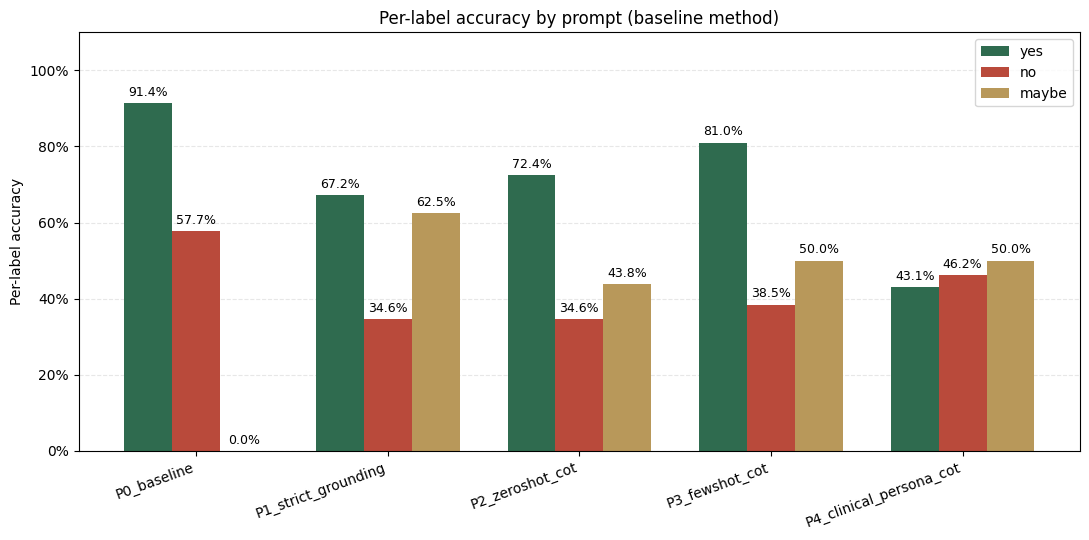

In [6]:
import matplotlib.pyplot as plt

sub = per_label[per_label['method'] == 'baseline'].copy()
if not sub.empty:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    x = range(len(sub))
    width = 0.25

    bars_yes   = ax.bar([i - width for i in x], sub['acc_yes'],   width, label='yes',   color='#2f6b4f')
    bars_no    = ax.bar(x,                       sub['acc_no'],    width, label='no',    color='#b94a3b')
    bars_maybe = ax.bar([i + width for i in x], sub['acc_maybe'], width, label='maybe', color='#b8985a')

    # Value labels in percent above each bar
    fmt = lambda v: f'{v * 100:.1f}%'
    ax.bar_label(bars_yes,   labels=[fmt(v) for v in sub['acc_yes']],   padding=3, fontsize=9)
    ax.bar_label(bars_no,    labels=[fmt(v) for v in sub['acc_no']],    padding=3, fontsize=9)
    ax.bar_label(bars_maybe, labels=[fmt(v) for v in sub['acc_maybe']], padding=3, fontsize=9)

    ax.set_xticks(list(x))
    ax.set_xticklabels(sub['prompt_id'].tolist(), rotation=20, ha='right')
    ax.set_ylabel('Per-label accuracy')
    ax.set_title('Per-label accuracy by prompt (baseline method)')
    ax.legend(loc='upper right')
    ax.set_ylim(0, 1.1)  # extra headroom for labels
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v * 100:.0f}%'))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()
else:
    print('No baseline-method results found. Run at least one prompt notebook first.')

## Heatmap multi-method (untuk full run P1 dan P3 di 4 method)

Cell di bawah hanya bermakna setelah notebook 02 dan 04 dijalankan dalam **full mode** (4 methods x 500 sampel). Akan menghasilkan heatmap `prompt x method` untuk setiap metrik utama, plus delta vs P0 baseline untuk visualisasi yang lebih jelas.

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Cek apakah ada lebih dari 1 method (kalau cuma baseline, heatmap kurang berguna)
unique_methods = df['method'].unique()
print(f'Methods available: {list(unique_methods)}')

if len(unique_methods) >= 2:
    # ===== Heatmap absolut per metrik =====
    metrics = ['accuracy', 'faithfulness', 'context_recall', 'answer_relevancy', 'context_precision']
    method_order = [m for m in ['baseline', 'qr', 'cr', 'qr_cr'] if m in unique_methods]
    prompt_order = sorted(df['prompt_id'].unique())

    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4 + 0.4 * len(prompt_order)))
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        pivot = df.pivot(index='prompt_id', columns='method', values=metric)
        pivot = pivot.reindex(index=prompt_order, columns=method_order)
        mat = pivot.values

        im = ax.imshow(mat, cmap='RdYlGn', vmin=0.4, vmax=1.0, aspect='auto')
        ax.set_xticks(range(len(method_order)))
        ax.set_xticklabels(method_order, rotation=30, ha='right', fontsize=9)
        ax.set_yticks(range(len(prompt_order)))
        ax.set_yticklabels([p.replace('_', '\n') for p in prompt_order], fontsize=8)
        ax.set_title(metric, fontsize=11, fontweight='bold')

        # Annotate dengan value persen
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                if not np.isnan(val):
                    color = 'white' if val < 0.55 or val > 0.85 else 'black'
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                            color=color, fontsize=9, fontweight='bold')

    fig.suptitle('Prompt x Method per Metric (absolute values)', y=1.02, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ===== Heatmap delta vs P0 baseline (kalau P0 ada) =====
    if 'P0_baseline' in prompt_order:
        fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4 + 0.4 * len(prompt_order)))
        if len(metrics) == 1: axes = [axes]

        for ax, metric in zip(axes, metrics):
            pivot = df.pivot(index='prompt_id', columns='method', values=metric)
            pivot = pivot.reindex(index=prompt_order, columns=method_order)

            # Baseline reference: P0 + baseline method
            ref = pivot.loc['P0_baseline', 'baseline'] if 'baseline' in pivot.columns else pivot.loc['P0_baseline'].iloc[0]
            delta = (pivot - ref) * 100  # convert to percentage points

            mat = delta.values
            vmax = max(abs(np.nanmin(mat)), abs(np.nanmax(mat)), 5)
            im = ax.imshow(mat, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
            ax.set_xticks(range(len(method_order)))
            ax.set_xticklabels(method_order, rotation=30, ha='right', fontsize=9)
            ax.set_yticks(range(len(prompt_order)))
            ax.set_yticklabels([p.replace('_', '\n') for p in prompt_order], fontsize=8)
            ax.set_title(f'Δ {metric}\n(vs P0+baseline)', fontsize=10, fontweight='bold')

            for i in range(mat.shape[0]):
                for j in range(mat.shape[1]):
                    val = mat[i, j]
                    if not np.isnan(val):
                        color = 'white' if abs(val) > vmax * 0.6 else 'black'
                        sign = '+' if val > 0 else ''
                        ax.text(j, i, f'{sign}{val:.1f}', ha='center', va='center',
                                color=color, fontsize=8, fontweight='bold')

        fig.suptitle('Delta vs P0 baseline (in percentage points)', y=1.02, fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
else:
    print('\nHanya 1 method (baseline). Heatmap multi-method butuh >= 2 method.')
    print('Jalankan notebook 02 dan 04 dalam full mode untuk mengaktifkan heatmap ini.')

Methods available: ['baseline']

Hanya 1 method (baseline). Heatmap multi-method butuh >= 2 method.
Jalankan notebook 02 dan 04 dalam full mode untuk mengaktifkan heatmap ini.


In [8]:
# ===== Heatmap Balanced Accuracy + Per-label Accuracy =====
# Balanced accuracy = rata-rata akurasi 3 kelas (lebih adil saat class imbalanced)

if len(unique_methods) >= 2:
    # Hitung balanced accuracy dari per_label
    per_label['balanced_acc'] = per_label[['acc_yes', 'acc_no', 'acc_maybe']].mean(axis=1)

    label_metrics = ['balanced_acc', 'acc_yes', 'acc_no', 'acc_maybe']
    method_order = [m for m in ['baseline', 'qr', 'cr', 'qr_cr'] if m in unique_methods]
    prompt_order = sorted(per_label['prompt_id'].unique())

    fig, axes = plt.subplots(1, len(label_metrics), figsize=(4 * len(label_metrics), 4 + 0.4 * len(prompt_order)))
    if len(label_metrics) == 1: axes = [axes]

    for ax, metric in zip(axes, label_metrics):
        pivot = per_label.pivot(index='prompt_id', columns='method', values=metric)
        pivot = pivot.reindex(index=prompt_order, columns=method_order)
        mat = pivot.values

        im = ax.imshow(mat, cmap='RdYlGn', vmin=0.0, vmax=1.0, aspect='auto')
        ax.set_xticks(range(len(method_order)))
        ax.set_xticklabels(method_order, rotation=30, ha='right', fontsize=9)
        ax.set_yticks(range(len(prompt_order)))
        ax.set_yticklabels([p.replace('_', '\n') for p in prompt_order], fontsize=8)
        ax.set_title(metric, fontsize=11, fontweight='bold')

        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                if not np.isnan(val):
                    color = 'white' if val < 0.4 or val > 0.8 else 'black'
                    ax.text(j, i, f'{val * 100:.0f}%', ha='center', va='center',
                            color=color, fontsize=9, fontweight='bold')

    fig.suptitle('Per-label Accuracy: Prompt x Method', y=1.02, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ===== Ranking final dengan balanced accuracy =====
    print('\n' + '=' * 70)
    print('RANKING (sorted by balanced accuracy, descending)')
    print('=' * 70)
    ranking = per_label.sort_values('balanced_acc', ascending=False)[
        ['prompt_id', 'method', 'balanced_acc', 'acc_yes', 'acc_no', 'acc_maybe']
    ]
    print(ranking.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    # ===== Best per criteria =====
    print('\n' + '=' * 70)
    print('BEST CONFIG PER CRITERIA')
    print('=' * 70)
    print(f'  Best balanced acc      : {ranking.iloc[0]["prompt_id"]} + {ranking.iloc[0]["method"]} ({ranking.iloc[0]["balanced_acc"]:.3f})')

    best_maybe = per_label.sort_values('acc_maybe', ascending=False).iloc[0]
    print(f'  Best maybe recall      : {best_maybe["prompt_id"]} + {best_maybe["method"]} ({best_maybe["acc_maybe"]:.3f})')

    best_overall = df.sort_values('accuracy', ascending=False).iloc[0]
    print(f'  Best overall accuracy  : {best_overall["prompt_id"]} + {best_overall["method"]} ({best_overall["accuracy"]:.3f})')

    best_faith = df.sort_values('faithfulness', ascending=False).iloc[0]
    print(f'  Best faithfulness      : {best_faith["prompt_id"]} + {best_faith["method"]} ({best_faith["faithfulness"]:.3f})')
else:
    print('Heatmap per-label butuh >= 2 method. Jalankan full run dulu.')

Heatmap per-label butuh >= 2 method. Jalankan full run dulu.


## Recommendation generator

Picks the best prompt per metric, and the best prompt for "maybe" class specifically (where current baseline is weakest).


In [9]:
if not df.empty:
    print('Best prompt per metric (across all methods):')
    for metric in ['accuracy', 'faithfulness', 'context_recall',
                   'answer_relevancy', 'context_precision']:
        idx = df[metric].idxmax()
        row = df.iloc[idx]
        print(f'  {metric:<20} : {row["prompt_id"]} on {row["method"]} = {row[metric]:.3f}')

    if not per_label.empty:
        print('\nBest prompt for "maybe" class (any method):')
        idx = per_label['acc_maybe'].idxmax()
        row = per_label.iloc[idx]
        print(f'  {row["prompt_id"]} on {row["method"]} : acc_maybe = {row["acc_maybe"]:.3f}')


Best prompt per metric (across all methods):
  accuracy             : P0_baseline on baseline = 0.680
  faithfulness         : P0_baseline on baseline = 0.900
  context_recall       : P3_fewshot_cot on baseline = 0.803
  answer_relevancy     : P0_baseline on baseline = 0.980
  context_precision    : P3_fewshot_cot on baseline = 0.730

Best prompt for "maybe" class (any method):
  P1_strict_grounding on baseline : acc_maybe = 0.625
